In [1]:
"""THIS IS THE BEGGINING OF OUR PROJECT"""

import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
### DATA PREPROCESSION

In [3]:
## Training Preprocessing

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'Train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=29,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 53696 files belonging to 29 classes.


In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'Val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=29,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 12067 files belonging to 29 classes.


In [6]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[138.   133.   156.  ]
   [134.5  129.5  152.5 ]
   [129.25 124.25 147.25]
   ...
   [114.75 109.75 132.75]
   [109.25 104.25 127.25]
   [106.5  101.5  124.5 ]]

  [[136.75 131.75 154.75]
   [135.25 130.25 153.25]
   [131.25 126.25 149.25]
   ...
   [110.25 105.25 128.25]
   [108.25 103.25 126.25]
   [106.   101.   124.  ]]

  [[134.25 129.25 152.25]
   [136.   131.   154.  ]
   [133.75 128.75 151.75]
   ...
   [108.75 103.75 126.75]
   [111.5  106.5  129.5 ]
   [114.75 109.75 132.75]]

  ...

  [[106.5   98.5  119.5 ]
   [107.    99.   120.  ]
   [104.5   96.5  117.5 ]
   ...
   [ 60.25  52.25  73.25]
   [ 65.5   57.5   78.5 ]
   [ 60.    52.    73.  ]]

  [[102.25  94.25 115.25]
   [100.75  92.75 113.75]
   [101.25  93.25 114.25]
   ...
   [ 67.5   59.5   80.5 ]
   [ 67.    59.    80.  ]
   [ 62.25  54.25  75.25]]

  [[103.    95.   116.  ]
   [105.25  97.25 118.25]
   [104.    96.   117.  ]
   ...
   [ 58.    50.    71.  ]
   [ 66.5   58.5   79.5 ]
   [ 62.    54.    7

In [7]:
## BUILDING MODEL 

In [8]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.models import Sequential

In [9]:
### CNN OR MODEL IS A TOOL USED IN DEEP LEARNING TO DEAL WITH IMAGE DATASET AND TO TRAIN OUR MODELS TO CLASSIFY IMAGES
### IT TAKES IMAGES AS INPUT AND APPLY CONVOLUTIONN POOLING AND FULLY CONNCETED PROCESSES TO CHANGE THIS IMAGES INTO INPUT FOR OUR NEURAL NETWORK BY FLATTENING
###
model = Sequential()

In [10]:
### WE NEED TO PERFORM CONVOLUTION AND POOLING (EITHER MAX OR AVG).
### CONV2D WITH FILTERS AND PADDING OR STRIDES 
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2, strides= 2))

C:\Users\EKOUA II\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2, strides= 2))

In [12]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2, strides= 2))

In [13]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2, strides= 2))

In [14]:
### WE NEED TO FLATTERN THE 2D CNN OUTPUT INTO A STRAIGHT LINE OF PIXELS TO BE USED AS INPUTS OF THE NEURAL NETWORK.
model.add(Flatten())

In [15]:
model.add(Dense(units=1024,activation='relu'))

In [16]:
# OUTPUT LAYER
model.add(Dense(units=29,activation='softmax'))

In [17]:
# COMPILING MODEL

In [18]:
from keras.optimizers import Adam, SGD, RMSprop
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      16,778,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 29)                  │          29,725 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,980,221 (68.59 MB)

 Trainable params: 17,980,221 (68.59 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
## MODEL TRAINING

In [21]:
training_history = model.fit(x=training_set, validation_data=validation_set, epochs=5) 

Epoch 1/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 2868s 2s/step - accuracy: 0.7784 - loss: 0.7394 - val_accuracy: 0.9090 - val_loss: 0.2796
Epoch 2/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 2747s 2s/step - accuracy: 0.9355 - loss: 0.1979 - val_accuracy: 0.9440 - val_loss: 0.1799
Epoch 3/5
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 2743s 2s/step - accuracy: 0.9617 - loss: 0.1125 - val_accuracy: 0.9448 - val_loss: 0.1685
Epoch 4/5
1170/1678 ━━━━━━━━━━━━━━━━━━━━ 13:03 2s/step - accuracy: 0.9754 - loss: 0.0736

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1678/1678 ━━━━━━━━━━━━━━━━━━━━ 2972s 2s/step - accuracy: 0.9806 - loss: 0.0572 - val_accuracy: 0.9403 - val_loss: 0.1982


In [22]:
model.save("plant_disease_model_2.keras")

In [20]:
from tensorflow.keras.models import load_model
model = load_model("plant_disease_model.keras")

In [21]:
# MODEL EVALUATION 

In [25]:
train_loss, train_acc = model.evaluate(training_set)

1852/1852 ━━━━━━━━━━━━━━━━━━━━ 842s 454ms/step - accuracy: 0.9895 - loss: 0.0319


In [26]:
print(train_loss, train_acc)

0.03192218765616417 0.9895336627960205


In [27]:
val_loss, val_acc = model.evaluate(validation_set)

417/417 ━━━━━━━━━━━━━━━━━━━━ 182s 437ms/step - accuracy: 0.9570 - loss: 0.1512


In [28]:
print(train_loss, train_acc)

0.03192218765616417 0.9895336627960205


In [29]:
epochs = {i for i in range (1,5)}
print(epochs)


{1, 2, 3, 4}


In [37]:
#SAVING THE HISTORY IN JSONG 
import json 
with open ("TRAINING_HISTORY.json","w") as f:
    json.dump(training_history.history,f)

NameError: name 'training_history' is not defined

In [38]:
# Load the JSON file
import json
with open("TRAINING_HISTORY.json", "r") as f:
    history_dict = json.load(f)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [36]:
# ACCURACY VISUALISATION 
history_dict['accuracy']

NameError: name 'history_dict' is not defined

In [14]:
print(len(epochs), len(history_dict['accuracy']))

4 5


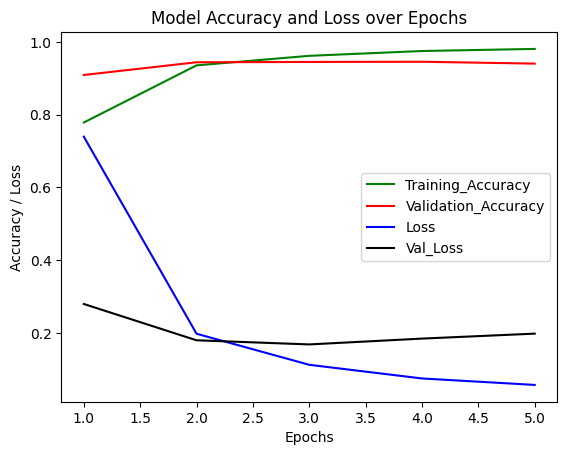

In [15]:
import matplotlib.pyplot as plt

# Define epochs (adjust the range to match your training length)
epochs = [i for i in range(1, 6)]

# Plot metrics from history_dict
plt.plot(epochs, history_dict['accuracy'], color='green', label='Training_Accuracy')
plt.plot(epochs, history_dict['val_accuracy'], color='red', label='Validation_Accuracy')
plt.plot(epochs, history_dict['loss'], color='blue', label='Loss')
plt.plot(epochs, history_dict['val_loss'], color='black', label='Val_Loss')

# Labels and title
plt.xlabel("Epochs")
plt.ylabel("Accuracy / Loss")
plt.title("Model Accuracy and Loss over Epochs")
plt.legend()
plt.show()



In [5]:
""" ###
MODEL EVALUATION WIH OTHER METRICS """

' ###\nMODEL EVALUATION WIH OTHER METRICS '

In [31]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'Val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=29,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 12067 files belonging to 29 classes.


In [41]:
class_names = validation_set.class_names
print(class_names)

['Apple - Apple Scab', 'Apple - Black Rot', 'Apple - Cedar Apple Rust', 'Apple - Healthy', 'Bell Pepper - Bacterial Spot', 'Bell Pepper - Healthy', 'Cherry - Healthy', 'Cherry - Powdery Mildew', 'Corn (Maize) - Cercospora Leaf Spot', 'Corn (Maize) - Common Rust', 'Corn (Maize) - Healthy', 'Corn (Maize) - Northern Leaf Blight', 'Grape - Black Rot', 'Grape - Esca (Black Measles)', 'Grape - Healthy', 'Grape - Leaf Blight', 'Peach - Bacterial Spot', 'Peach - Healthy', 'Potato - Early Blight', 'Potato - Healthy', 'Potato - Late Blight', 'Strawberry - Healthy', 'Strawberry - Leaf Scorch', 'Tomato - Bacterial Spot', 'Tomato - Early Blight', 'Tomato - Healthy', 'Tomato - Late Blight', 'Tomato - Septoria Leaf Spot', 'Tomato - Yellow Leaf Curl Virus']
